# Introducción
Objetivo Principal: Comprender la estructura, calidad y comportamiento del dataset antes de iniciar el proceso de modelado.
Variable objetivo: Revenue

Explicacion de cada columna:

- Administrative: Cantidad de páginas administrativas visitadas.
- Administrative_Duration: Tiempo total (en segundos) dedicado a páginas administrativas.
- Informational: Cantidad de páginas informativas.
- Informational_Duration: Tiempo dedicado a esas páginas.
- ProductRelated: Cantidad de páginas de productos visitadas.
- ProductRelated_Duration: Tiempo total observando productos.
- BounceRates: Representa el porcentaje de sesiones en las que el usuario abandonó el sitio casi inmediatamente, sin interacción significativa.
- ExitRates: Probabilidad de que una página sea la última visitada antes de abandonar el sitio.
- PageValues: Es una métrica que estima el valor económico esperado de una página en función de su contribución a conversiones.
- SpecialDay: Indica la cercanía de la sesión a una fecha comercial especial.
- OperatingSystems: Sistema operativo.
- Browser: Navegador.
- Region: Región geográfica del visitante.
- TrafficType: Fuente de tráfico.
- Month: Mes de la sesión.
- Weekend: Indica si la sesión ocurrió durante el fin de semana.
- VisitorType: Tipo de visitante.
- Revenue: Variable binaria que indica si la sesión terminó en una compra.

## Analisis Exploratorio

### Impoertación de librerías

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### Configuracion de rutas

In [63]:
# Ruta base del proyecto
PROJECT_ROOT = Path.cwd().parent

# Ruta del dataset
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "online_shoppers_intention.csv"
)

print(f"Ruta del proyecto: {PROJECT_ROOT}")
print(f"Ruta del dataset: {DATA_PATH}")
print(f"¿Existe el archivo?: {DATA_PATH.exists()}")

Ruta del proyecto: c:\Users\Lucas\OneDrive\Desktop\Pf
Ruta del dataset: c:\Users\Lucas\OneDrive\Desktop\Pf\data\raw\online_shoppers_intention.csv
¿Existe el archivo?: True


### Carga del dataset

In [64]:
df = pd.read_csv("C:/Users/Lucas/OneDrive/Desktop/pf/data/raw/online_shoppers_intention.csv")

df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


### Descripción del dataset

In [65]:
df.shape

(12330, 18)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [67]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


In [68]:
df.describe()

df.describe(include="object")

,Month,VisitorType
count,12330,12330
unique,10,3
top,May,Returning_Visitor
freq,3364,10551


### Valores faltantes


In [69]:
missing = pd.DataFrame({
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje": round(df.isnull().mean()*100,2)
})

missing

,Valores faltantes,Porcentaje
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


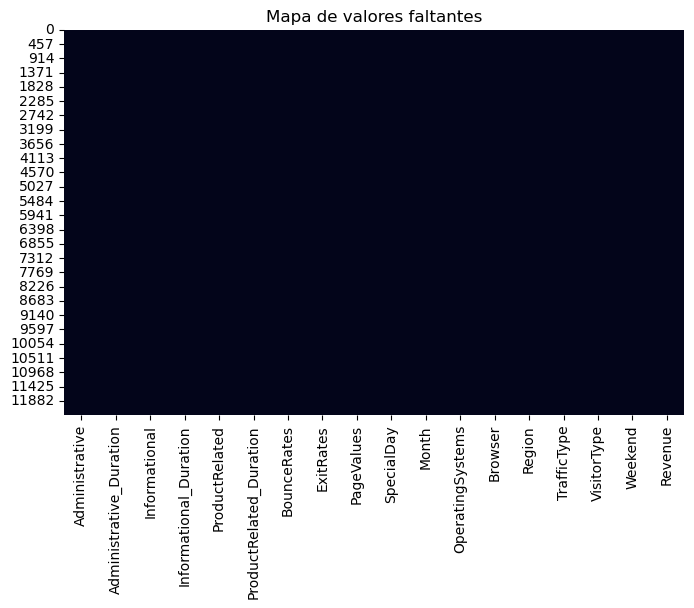

In [70]:
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Mapa de valores faltantes")

plt.show()

### Duplicados

In [71]:
duplicated_rows = df.duplicated().sum()
duplicated_percentage = duplicated_rows / len(df) * 100

print(f"Registros duplicados: {duplicated_rows:,}")
print(f"Porcentaje de duplicados: {duplicated_percentage:.2f}%")

Registros duplicados: 125
Porcentaje de duplicados: 1.01%


In [72]:
if duplicated_rows > 0:
    display(
        df[df.duplicated(keep=False)]
        .sort_values(by=df.columns.tolist())
        .head(10)
    )
else:
    print("No se detectaron registros duplicados exactos.")

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


### Distribución de la variable objetivo

In [73]:
# True: realizó una compra
# False: no compró
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

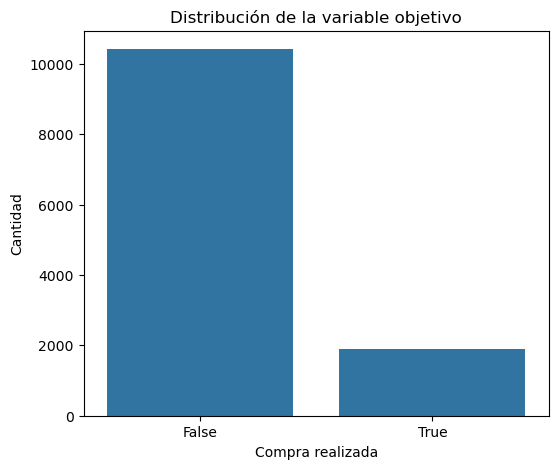

In [74]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Revenue")

plt.title("Distribución de la variable objetivo")

plt.xlabel("Compra realizada")

plt.ylabel("Cantidad")

plt.show()

In [75]:
round(df["Revenue"].value_counts(normalize=True)*100,2)

Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64

### Variables Númericas

In [76]:
numerical_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]


In [77]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742


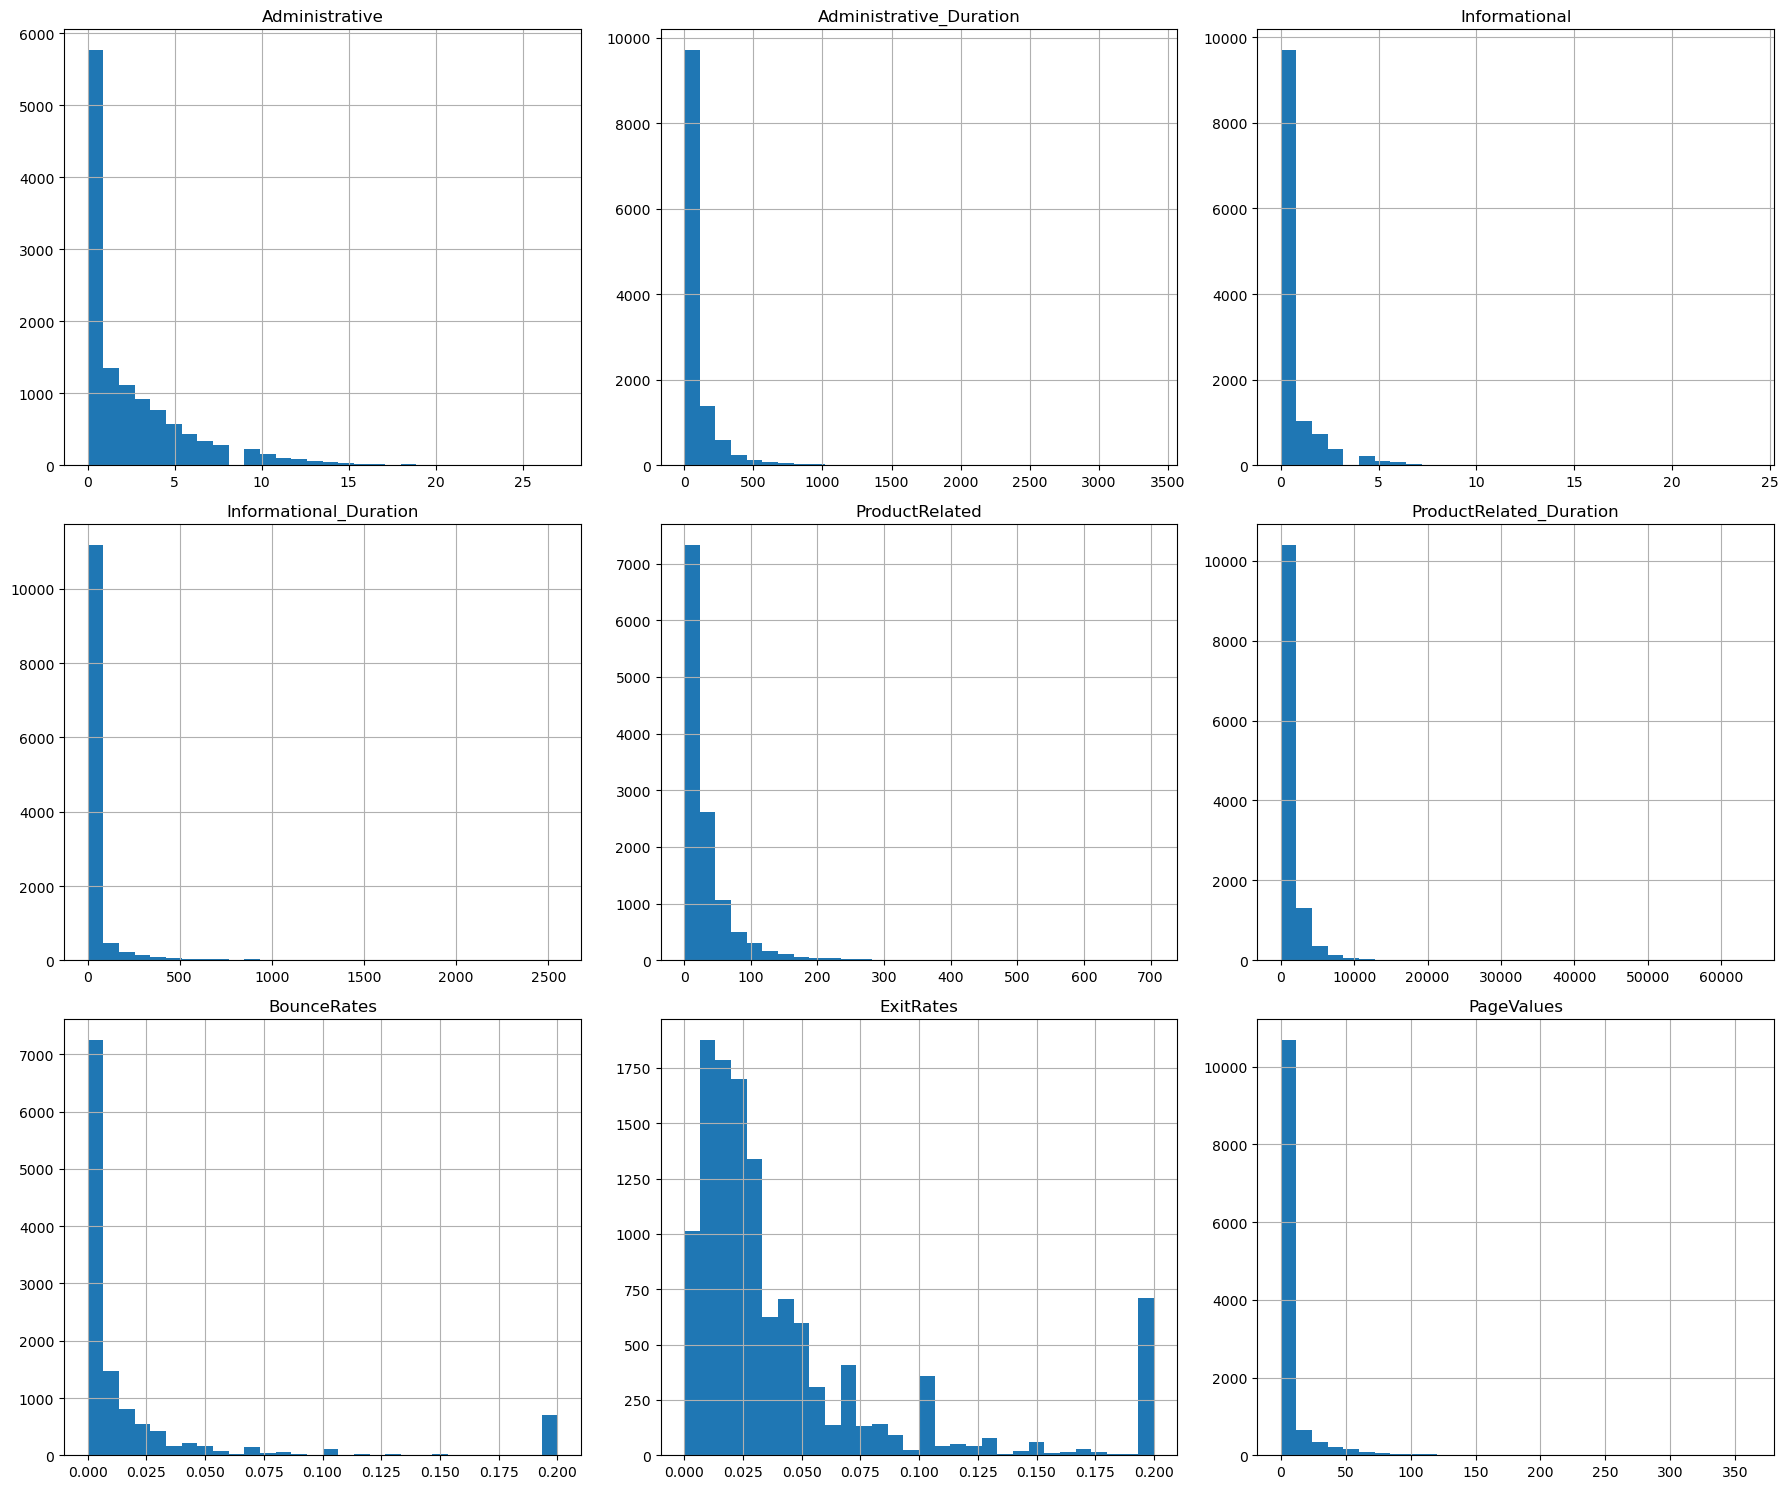

In [78]:
df[numerical_columns].hist(
    figsize=(18,15),
    bins=30
)

plt.tight_layout()

plt.show()

### Variables Categóricas

In [79]:
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
    "SpecialDay"
]

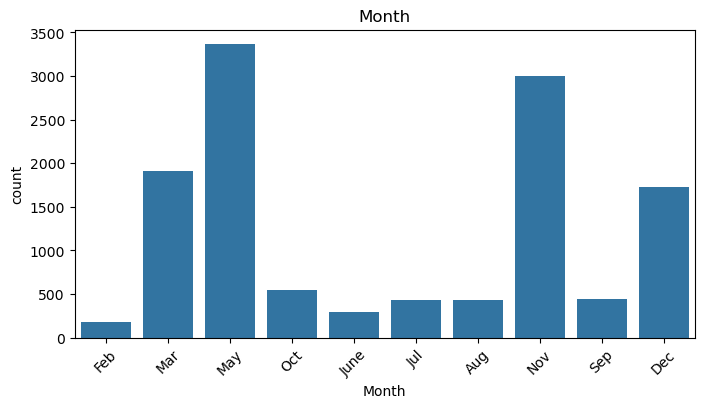

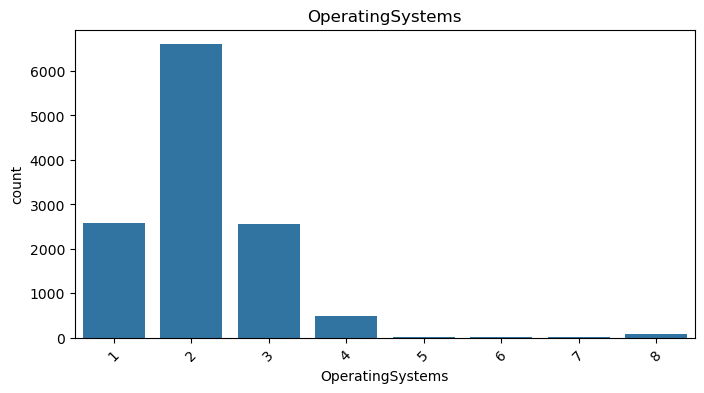

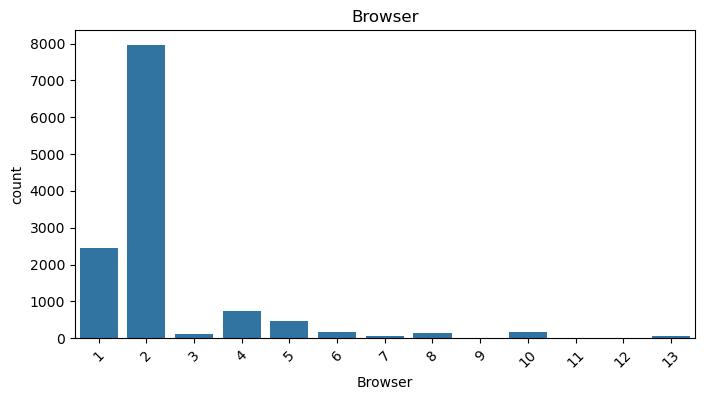

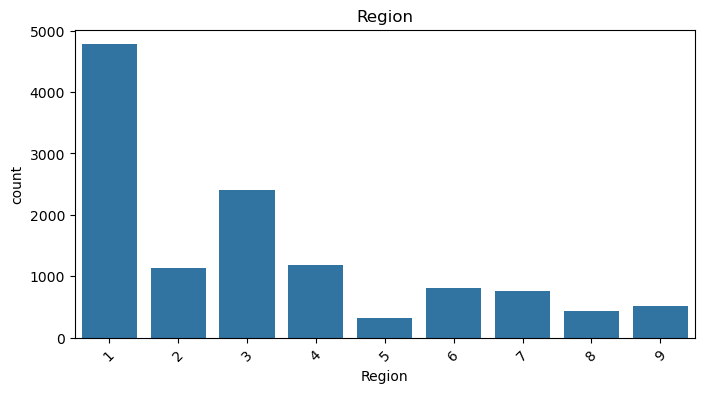

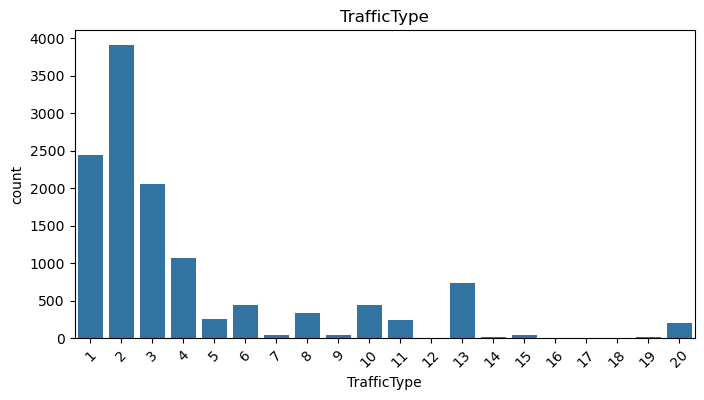

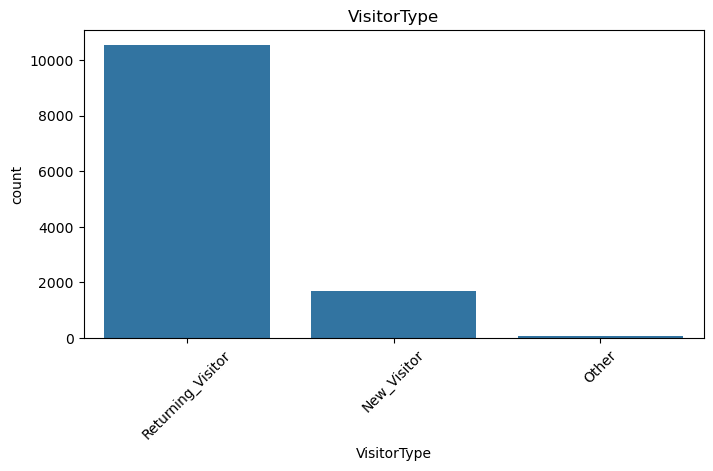

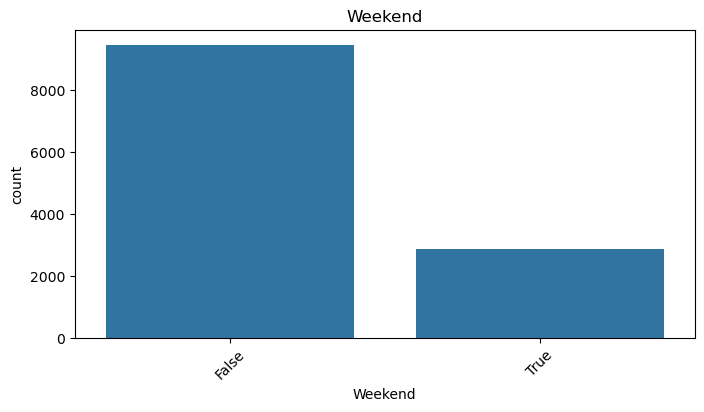

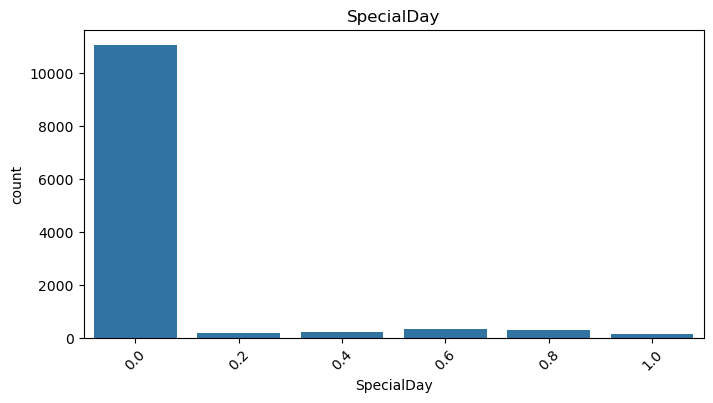

In [80]:
for column in categorical_columns:
    
    plt.figure(figsize=(8,4))
    
    sns.countplot(data=df, x=column)
    
    plt.title(column)
    
    plt.xticks(rotation=45)
    
    plt.show()

### Análisis univariado

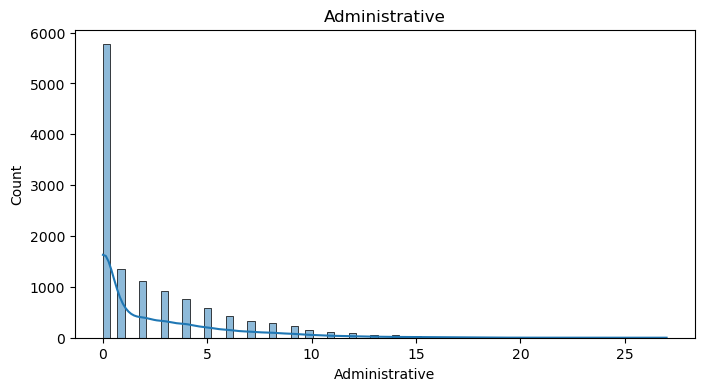

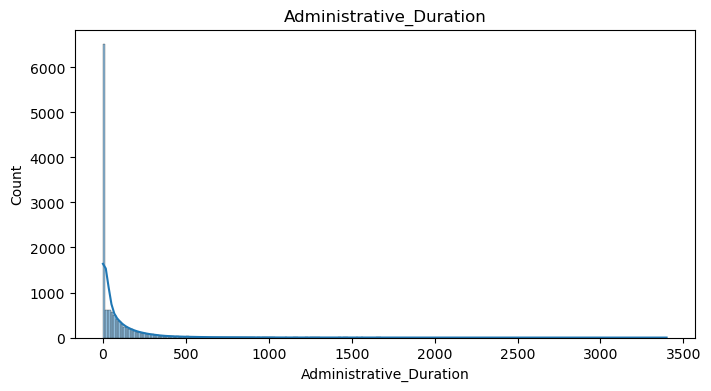

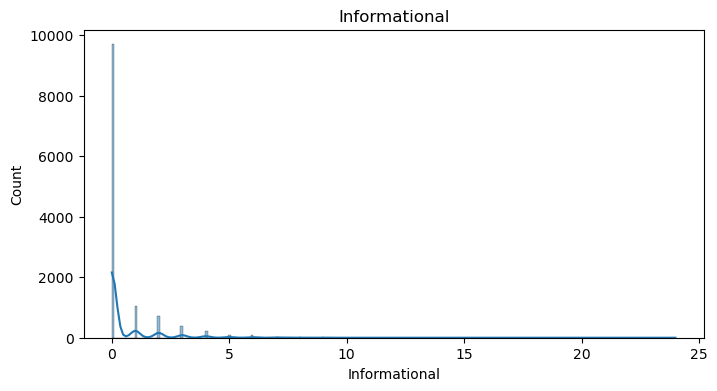

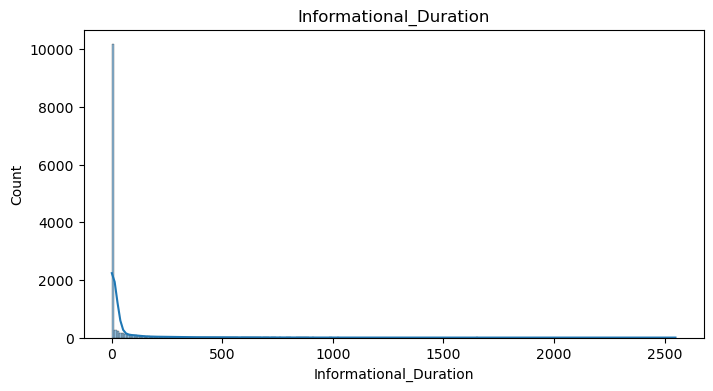

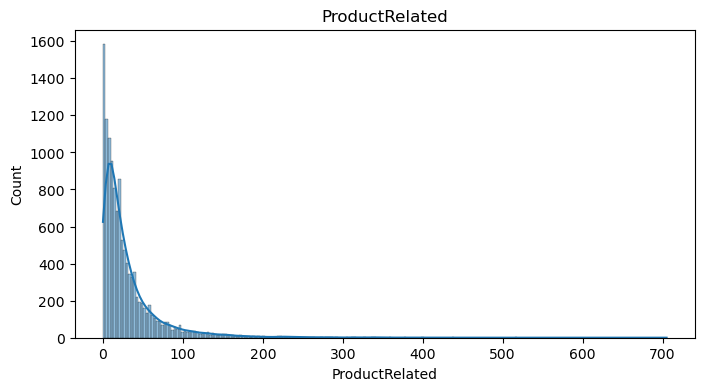

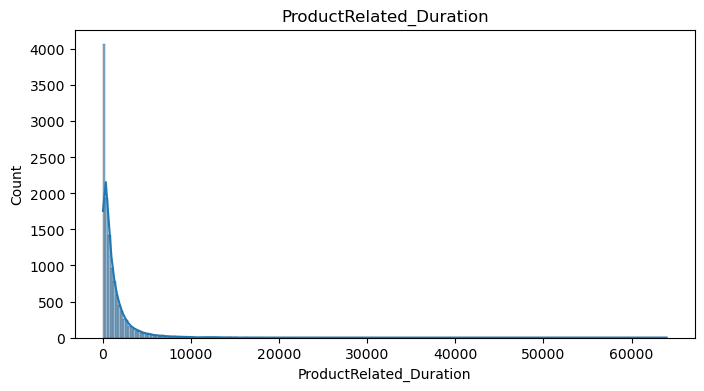

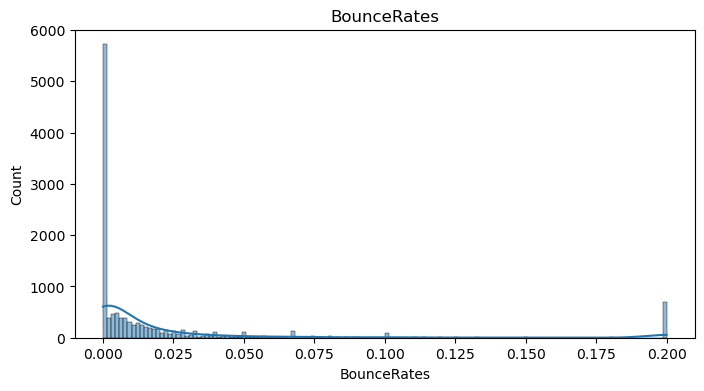

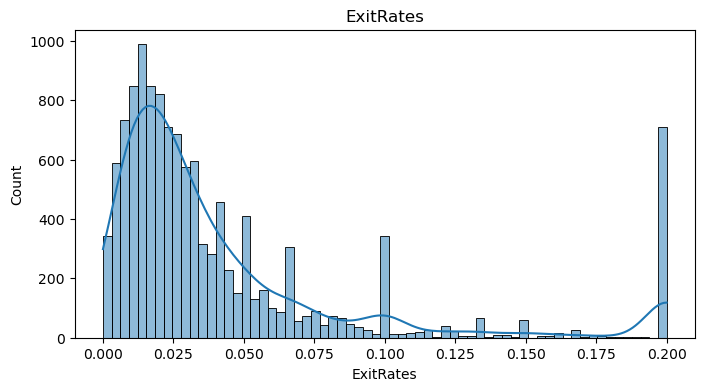

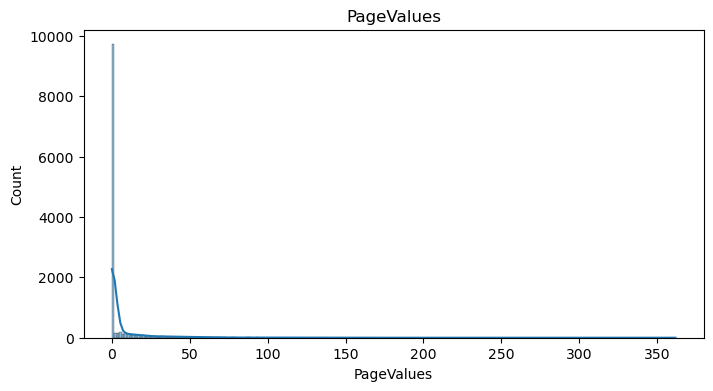

In [81]:
for column in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.histplot(df[column], kde=True)

    plt.title(column)

    plt.show()

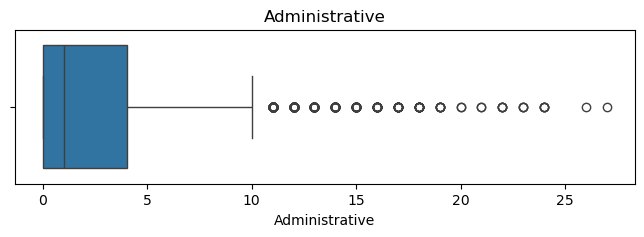

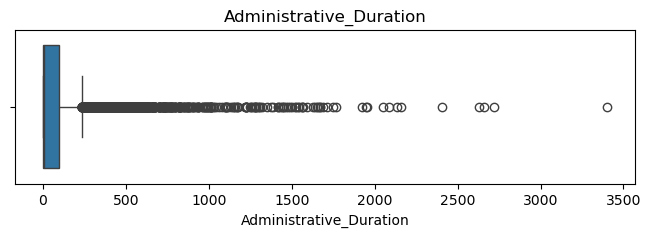

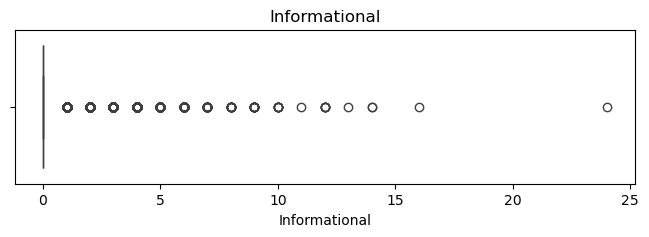

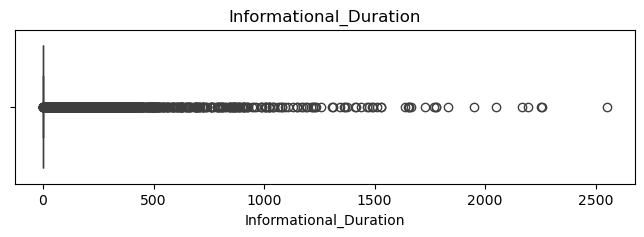

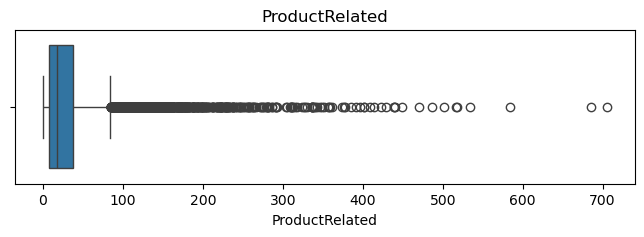

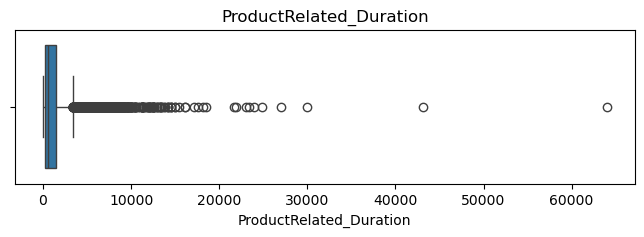

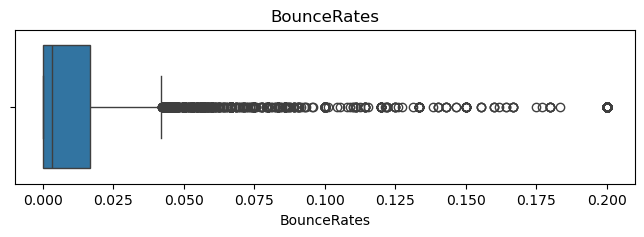

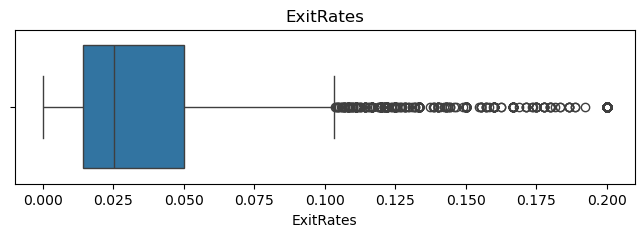

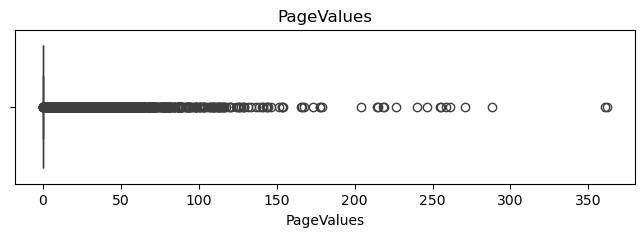

In [82]:
for column in numerical_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

### Análisis bivariado

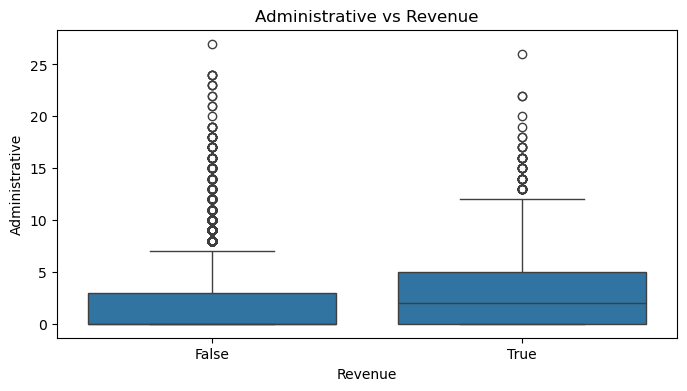

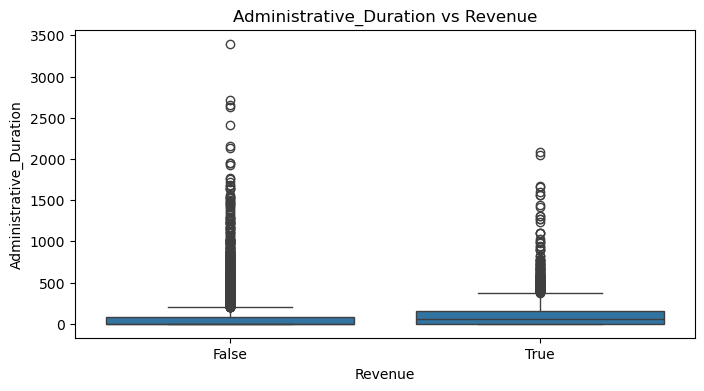

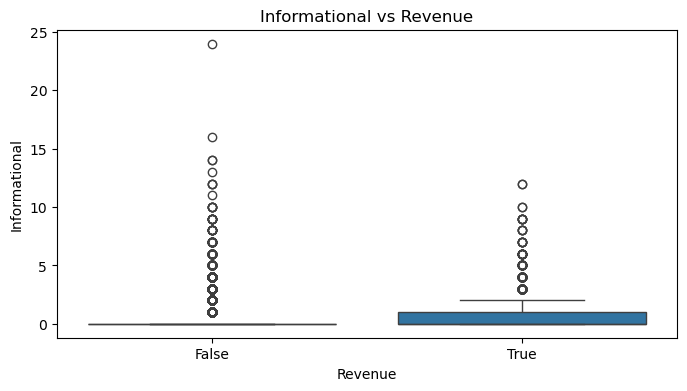

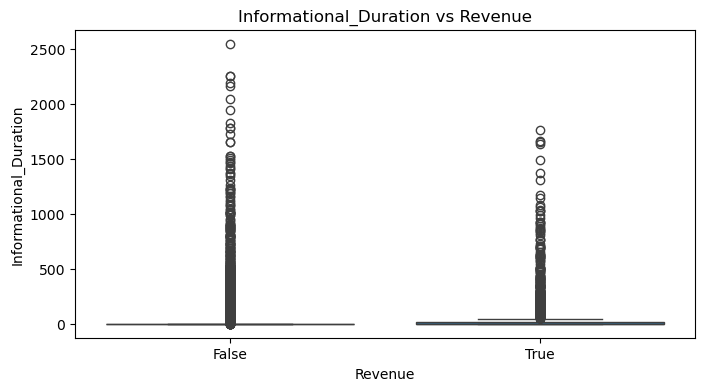

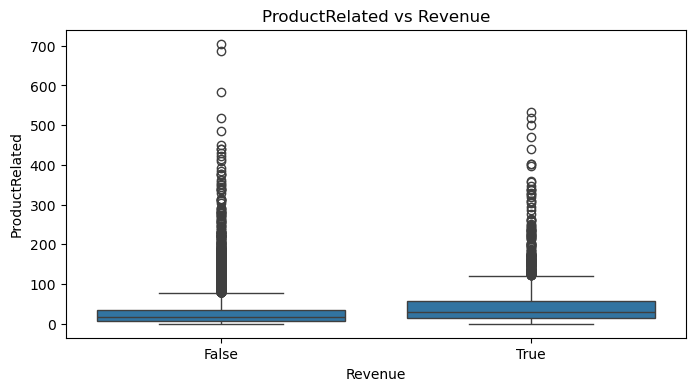

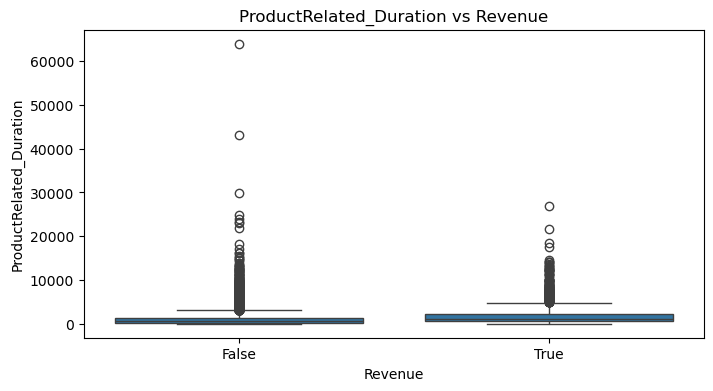

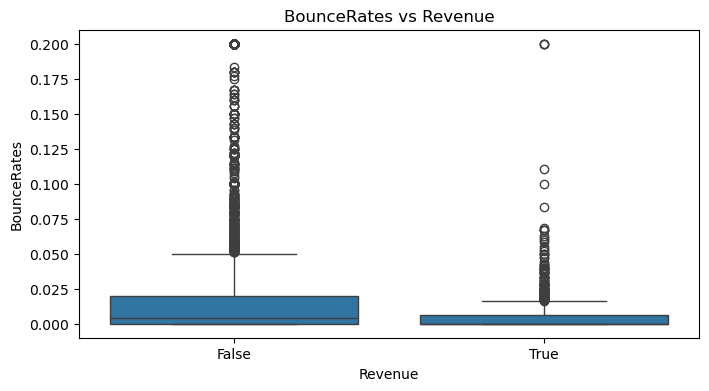

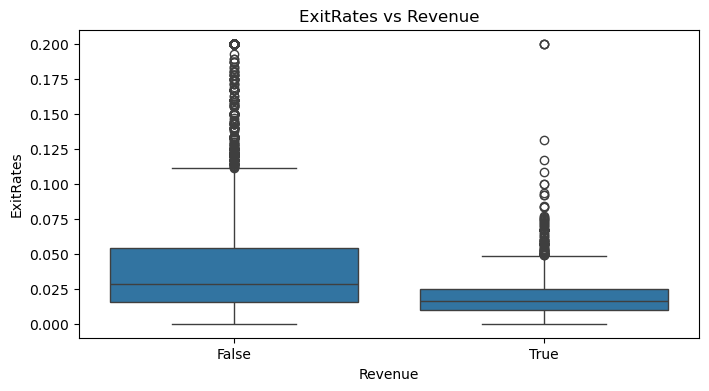

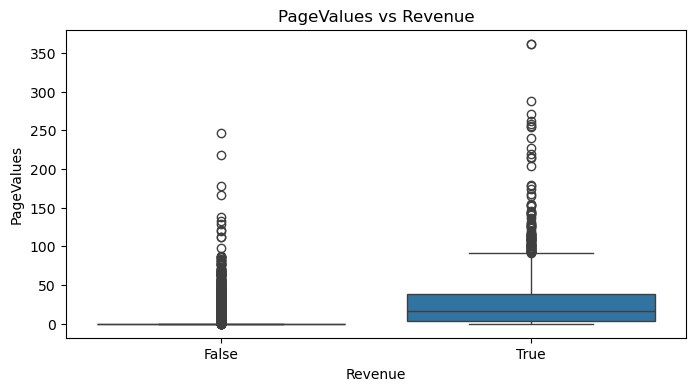

In [83]:
#Variables numéricas vs Revenue
for column in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x="Revenue",
        y=column
    )

    plt.title(f"{column} vs Revenue")

    plt.show()

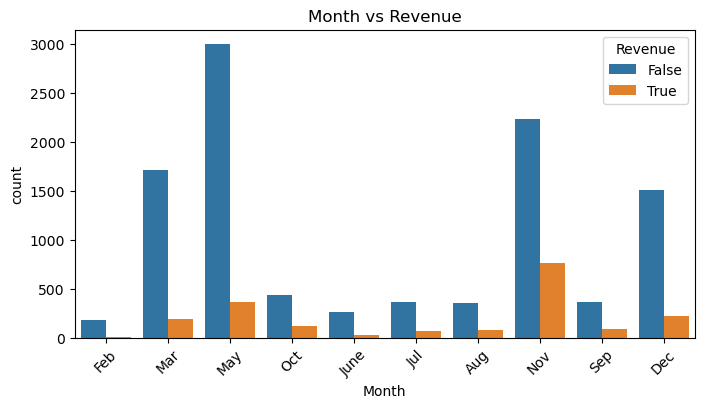

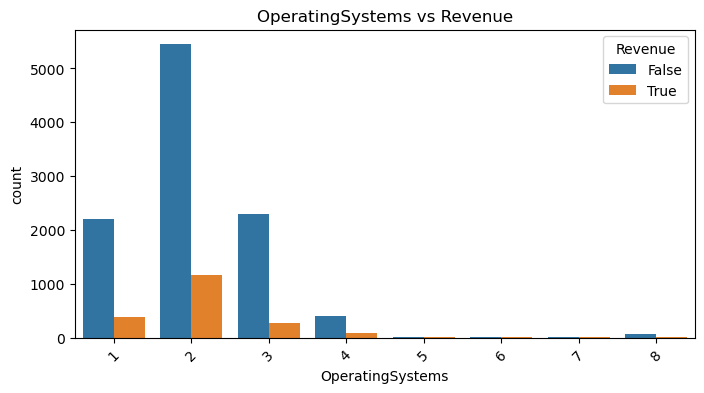

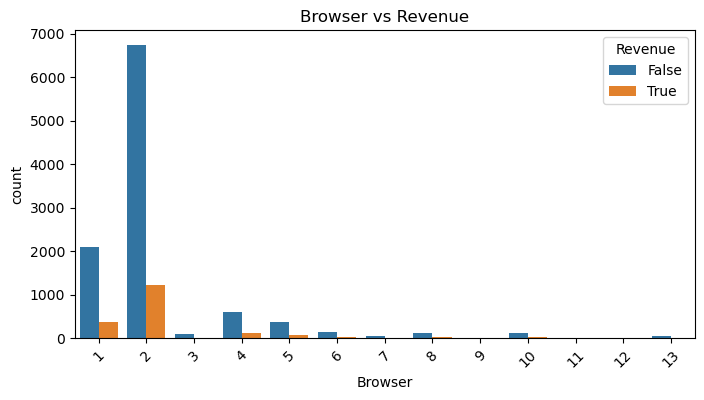

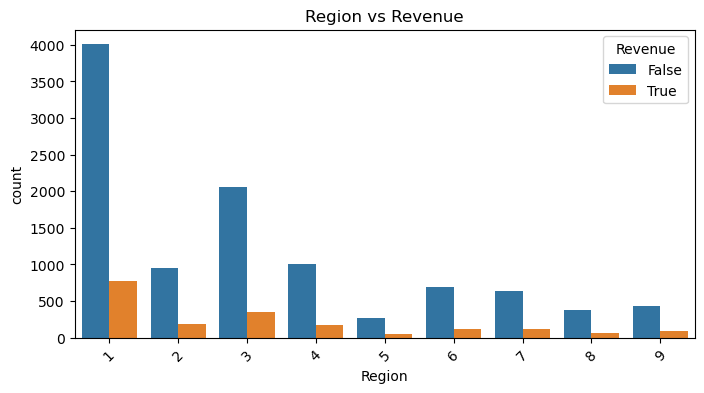

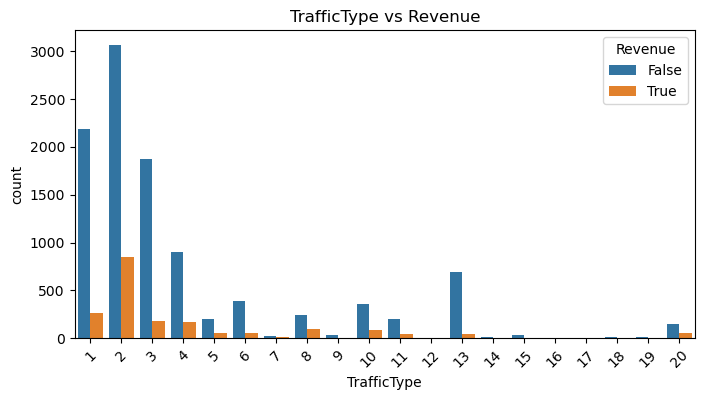

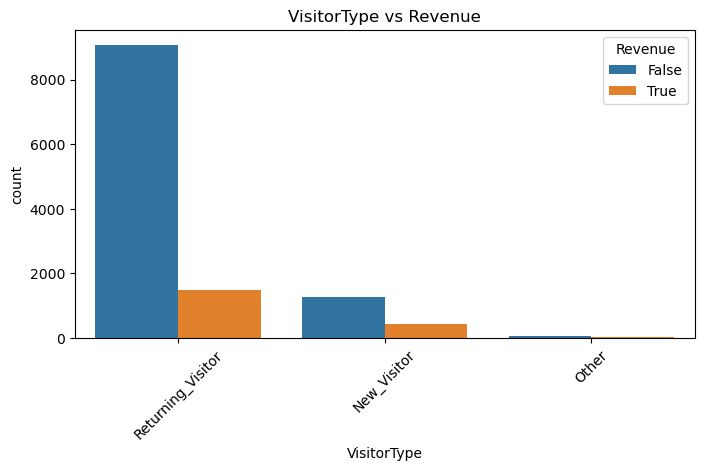

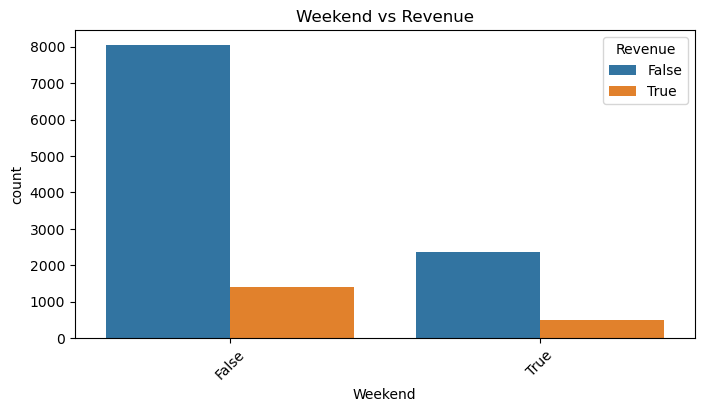

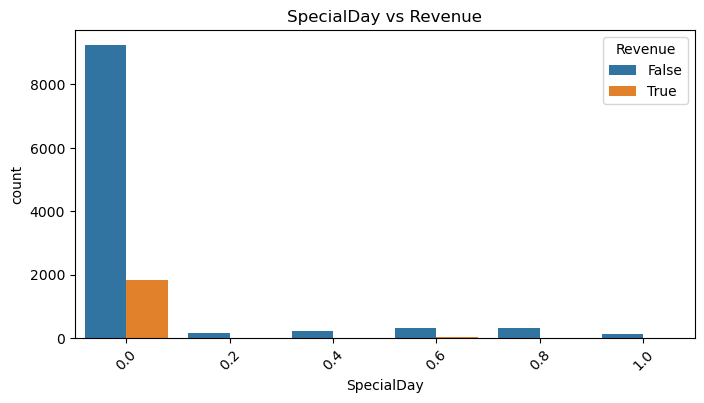

In [84]:
#Variables categóricas vs Revenue
for column in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=column,
        hue="Revenue"
    )

    plt.xticks(rotation=45)

    plt.title(f"{column} vs Revenue")

    plt.show()

### Correlaciones

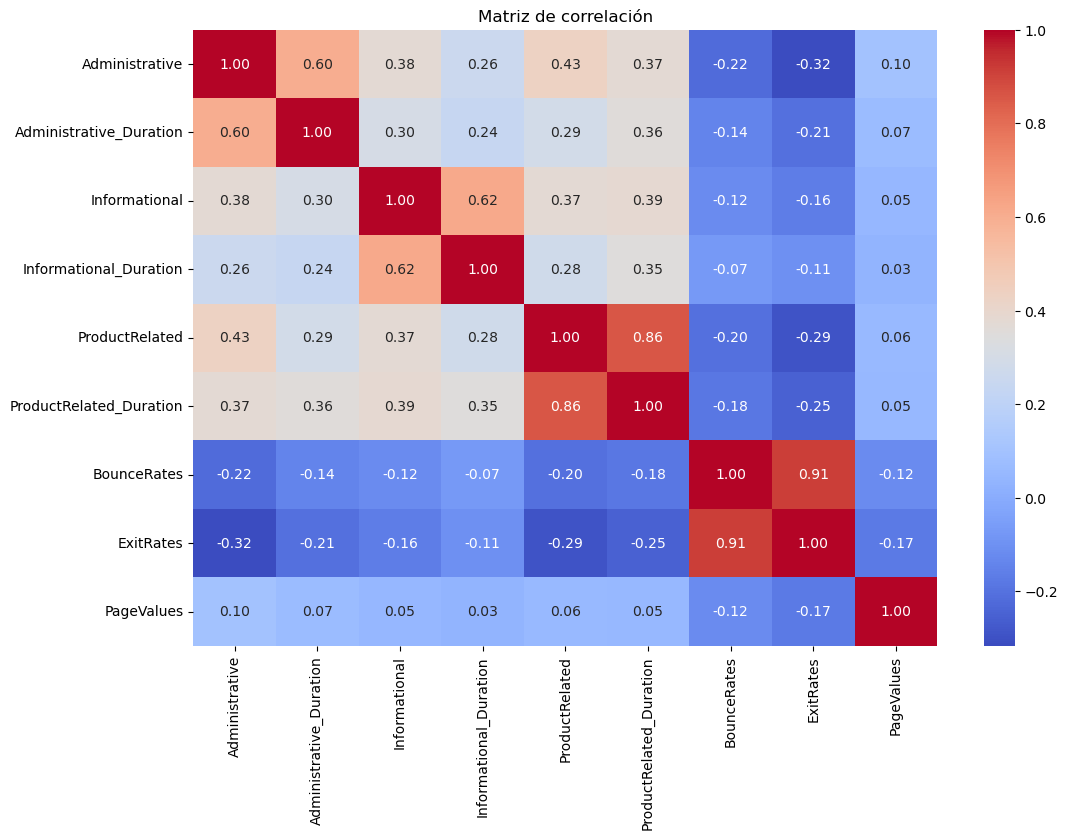

In [85]:
correlation = df[numerical_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.show()

### Outliers

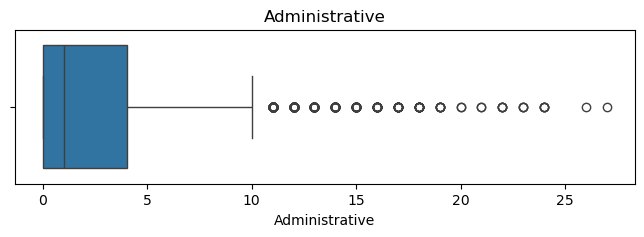

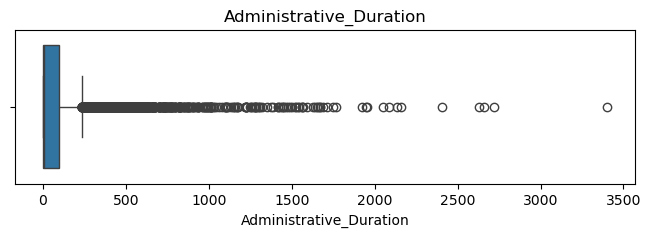

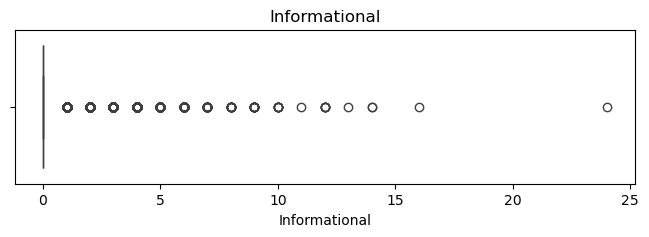

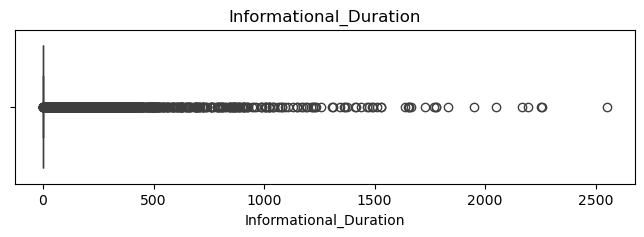

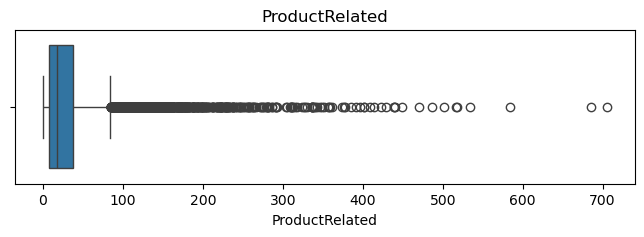

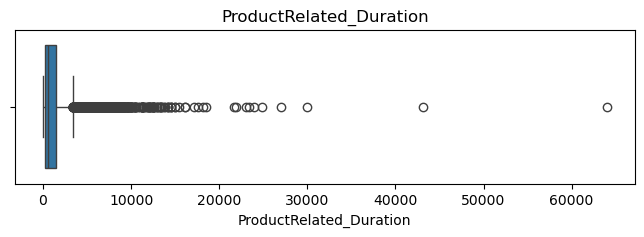

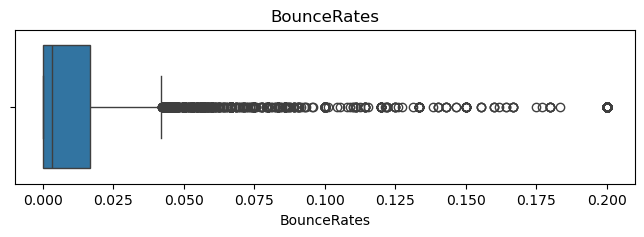

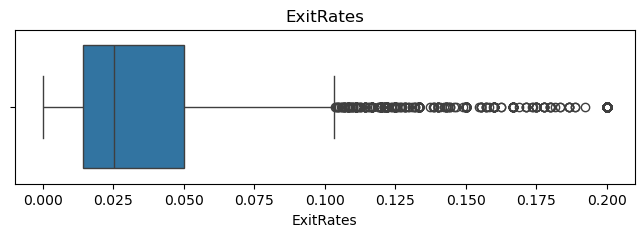

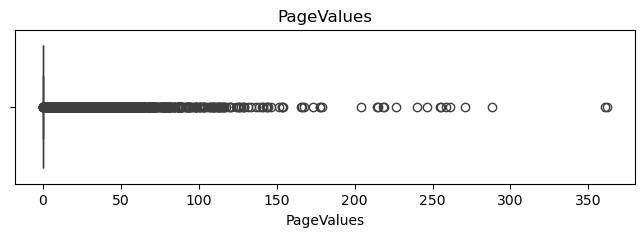

In [86]:
for column in numerical_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

In [87]:
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    outliers = df[
        (df[column] < Q1 - 1.5*IQR) |
        (df[column] > Q3 + 1.5*IQR)
    ]

    print(f"{column}: {len(outliers)} outliers")

Administrative: 404 outliers
Administrative_Duration: 1172 outliers
Informational: 2631 outliers
Informational_Duration: 2405 outliers
ProductRelated: 987 outliers
ProductRelated_Duration: 961 outliers
BounceRates: 1551 outliers
ExitRates: 1099 outliers
PageValues: 2730 outliers


### Conclusiones del EDA
A partir del Análisis Exploratorio de Datos realizado sobre el dataset **Online Shoppers Purchasing Intention**, se obtuvieron los siguientes hallazgos:

- El conjunto de datos está compuesto por **12.330 registros** y **18 variables**, proporcionando una base de información adecuada para el desarrollo de un modelo de clasificación orientado a predecir la intención de compra de los usuarios.

- No se identificaron **valores faltantes**, por lo que no será necesario realizar procesos de imputación durante la etapa de preprocesamiento.

- Se detectaron **125 registros duplicados**, equivalentes aproximadamente al **1,01 %** del dataset. Debido a que cada fila representa una sesión de navegación y no existe un identificador único de usuario, estos registros no serán eliminados automáticamente, ya que podrían corresponder a sesiones distintas con características similares.

- La variable objetivo **Revenue** presenta un **desbalance de clases**, donde aproximadamente el **84,53 %** de las sesiones no finalizaron en una compra, mientras que solo el **15,47 %** terminaron en una conversión. Este comportamiento deberá considerarse durante el entrenamiento de los modelos y la selección de métricas de evaluación.

- El análisis de las variables numéricas permitió observar diferentes distribuciones y la presencia de valores atípicos en varias de ellas. No obstante, estos valores no serán eliminados de manera automática, ya que pueden representar comportamientos reales de navegación y contener información relevante para la predicción.

- Las variables categóricas permitieron identificar diferentes perfiles de usuarios y características de las sesiones, aportando información complementaria que podría contribuir significativamente al desempeño del modelo.

- El análisis bivariado y la matriz de correlación facilitaron una primera comprensión de la relación entre las variables predictoras y la variable objetivo, proporcionando una base para la selección de características en las siguientes etapas del proyecto.